[← Back to Index](index)

# Matplotlib tutorial

This notebook provides an overview of and playground for **matplotlib.pyplot**, a visualization framework for Python.

## Using this notebook

The tutorial is best viewed in an interactive Jupyter Notebook environment so you can edit, modify, run, and iterate on the code yourself—the best way to learn! If you're reading a static (non-interactive) version of this page on our website, you can open an interactive version with a single click using [Binder](https://mybinder.org/v2/gh/makeabilitylab/signals/master?filepath=Tutorials%2FIntroToMatplotlib.ipynb) or [Colab](https://colab.research.google.com/github/makeabilitylab/signals/blob/master/Tutorials/IntroToMatplotlib.ipynb). You can also clone our [GitHub repository](https://github.com/makeabilitylab/signals) and run this notebook locally using [Jupyter Notebook](https://jupyter.org/).


## Acknowledgments
This tutorial is based on: 

- Matplotlib's official [usage guide](https://matplotlib.org/tutorials/introductory/usage.html#sphx-glr-tutorials-introductory-usage-py)
- Matplotlib's official [Pyplot tutorial1](https://matplotlib.org/users/pyplot_tutorial.html) and [Pyplot tutorial2](https://matplotlib.org/tutorials/introductory/pyplot.html). See also their 
[Tutorials page](https://matplotlib.org/tutorials/index.html), which provides additional in-depth tutorials, and their [gallery](https://matplotlib.org/tutorials/introductory/sample_plots.html) of example plots.
- Chapter 4 of Jake VanderPlas' *Python Data Science Handbook* on [Visualization with Matplotlib](https://jakevdp.github.io/PythonDataScienceHandbook/index.html#4.-Visualization-with-Matplotlib)
- Stanford CSE231n [Python Numpy Tutorial](https://cs231n.github.io/python-numpy-tutorial/#matplotlib)

## About this Notebook

This Notebook derives from the above sources. Updates were written by Professor Jon E. Froehlich at the University of Washington along with feedback from students. It is made available freely online as an [open educational resource](https://en.wikipedia.org/wiki/Open_educational_resources) at the teaching website: https://makeabilitylab.github.io/physcomp/. 

The [website](https://github.com/makeabilitylab/physcomp), [Notebook code](https://github.com/makeabilitylab/signals), and [Arduino code](https://github.com/makeabilitylab/arduino) are all open source using the MIT license.

Please file a GitHub Issue or Pull Request for changes/comments or email me directly.

## Anatomy of a matplotlib chart
<img src="https://matplotlib.org/_images/anatomy.png" width="500">

## The basics
[matplotlib.pyplot](https://matplotlib.org/api/pyplot_api.html#module-matplotlib.pyplot) provides a MATLAB-like plotting environment for Python. It's easy and fast to plot a range of visualizations. For example, let's plot the array `[1,2,3,4]`:

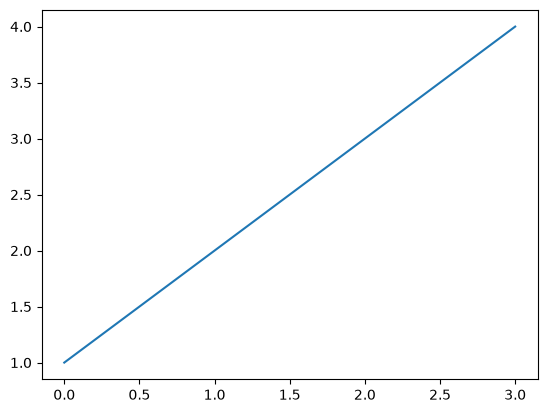

In [1]:
import matplotlib.pyplot as plt
plt.plot([1,2,3,4])
plt.show()

### Adding titles, axis labels, and a legend
Let's redraw this plot but now with a title, axis labels, and a legend:

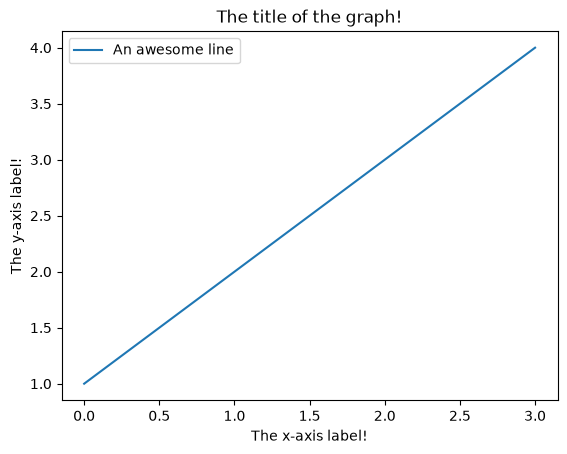

In [2]:
x_vals = [1,2,3,4]
plt.plot(x_vals, label="An awesome line")
plt.ylabel('The y-axis label!')
plt.xlabel('The x-axis label!')
plt.title("The title of the graph!")
plt.legend()
plt.show()

### Adding both x and y data

You may be wondering why the x-axis ranges from 0-3 and the y-axis from 1-4. If you provide a single list or array to the [plot()](https://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.plot) command, matplotlib assumes it is a sequence of y values, and automatically generates the x values for you.

[plot()](https://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.plot) is a versatile command, and will take an arbitrary number of arguments. For example, to plot x versus y, you can issue the command:

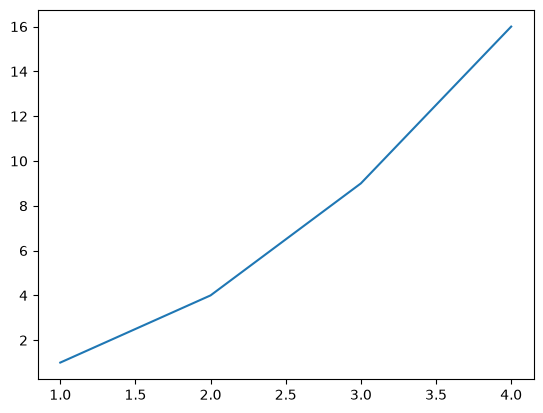

In [3]:
x_vals = [1,2,3,4]
y_vals = [1, 4, 9, 16]
plt.plot(x_vals, y_vals)
plt.show()

Here's another example using NumPy:

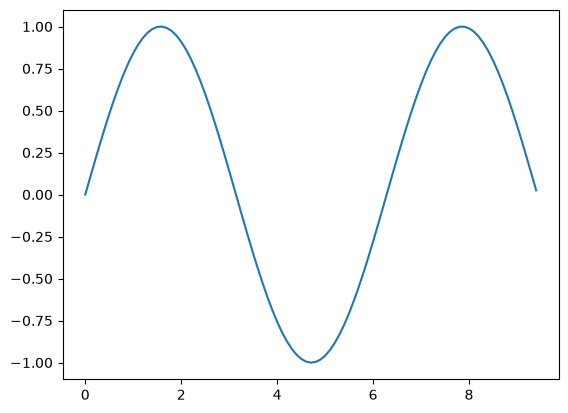

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Compute the x and y coordinates for points on a sine curve
x = np.arange(0, 3 * np.pi, 0.1)
y = np.sin(x)

# Plot the points using matplotlib
plt.plot(x, y)
plt.show()  # You must call plt.show() to make graphics appear.

### Setting axis ranges
You can set the [xmin, xmax, ymin, ymax] of the plot using the [axis()](https://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.axis) command. So, for example:

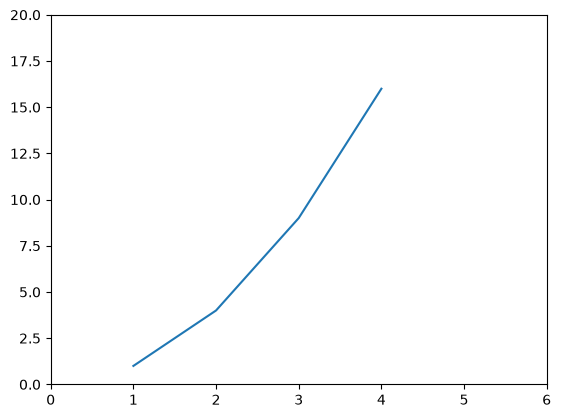

In [5]:
import matplotlib.pyplot as plt
plt.plot(x_vals, y_vals)
plt.axis([0, 6, 0, 20])
plt.show()

### Resizing the plot
We can also resize the plot using figsize. This will be important later when we make multiple plots together.

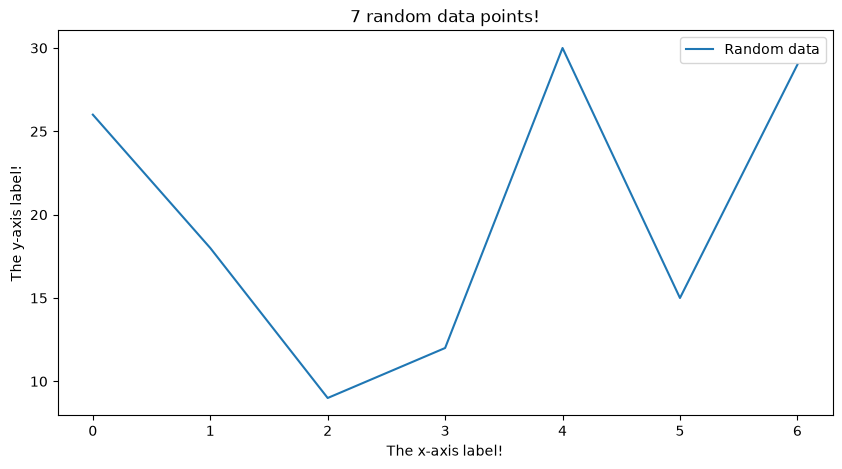

In [6]:
import random 

num_rand_data_points = 7
plt.figure(figsize=(10, 5), facecolor='w', edgecolor='k')
x_vals = [random.randrange(1, 50, 1) for i in range(num_rand_data_points)]
plt.plot(x_vals, label="Random data")
plt.ylabel('The y-axis label!')
plt.xlabel('The x-axis label!')
plt.title("{} random data points!".format(num_rand_data_points))
plt.legend()
plt.show()

### Plotting multiple values 
You can plot multiple lines too:

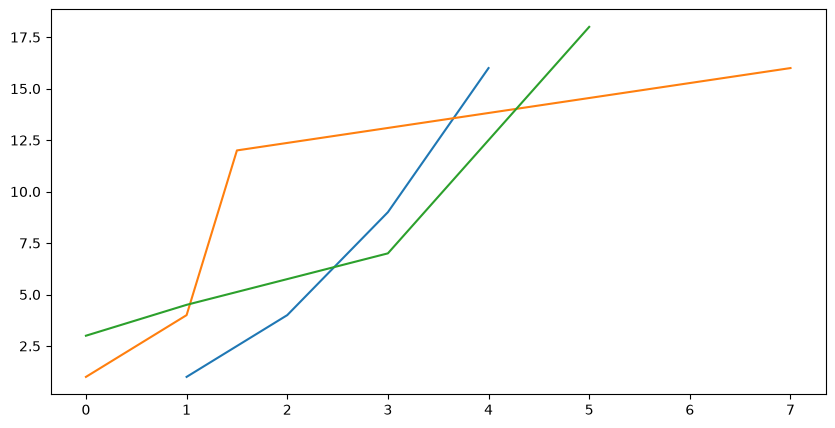

In [7]:
# setup the data
(x1_vals, y1_vals) = ([1,2,3,4], [1, 4, 9, 16])
(x2_vals, y2_vals) = ([0,1,1.5,7], [1,4,12,16])
(x3_vals, y3_vals) = ([0,1,3,5], [3,4.5,7,18])

# plot the data
plt.figure(figsize=(10, 5))
plt.plot(x1_vals, y1_vals)
plt.plot(x2_vals, y2_vals)
plt.plot(x3_vals, y3_vals)
plt.show()

An even more compact way of doing this:

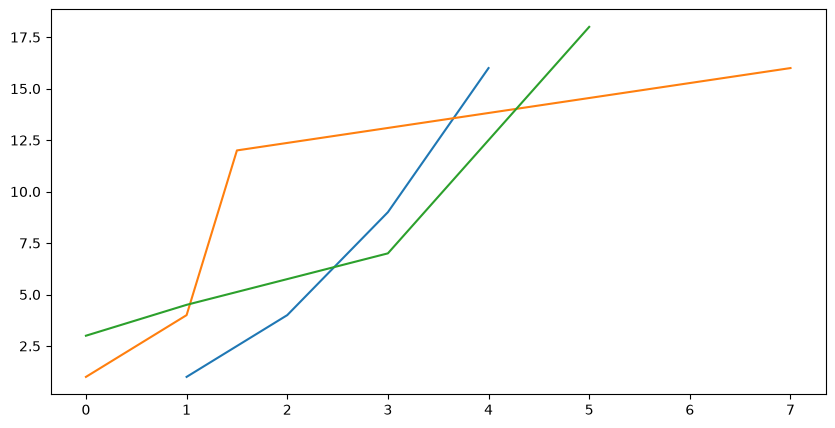

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(x1_vals, y1_vals, x2_vals, y2_vals, x3_vals, y3_vals)
plt.show()

And again with NumPy:

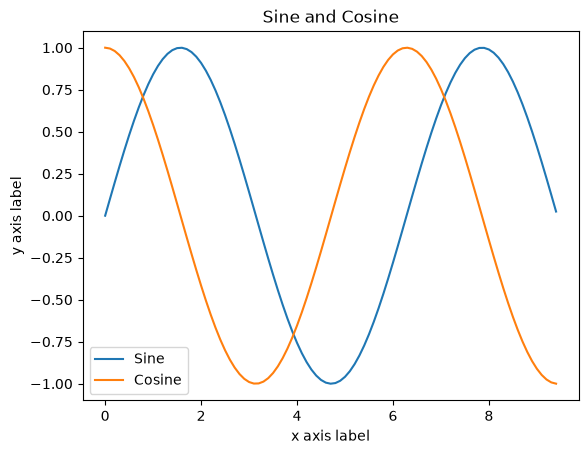

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Compute the x and y coordinates for points on sine and cosine curves
x = np.arange(0, 3 * np.pi, 0.1)
y_sin = np.sin(x)
y_cos = np.cos(x)

# Plot the points using matplotlib
plt.plot(x, y_sin)
plt.plot(x, y_cos)
plt.xlabel('x axis label')
plt.ylabel('y axis label')
plt.title('Sine and Cosine')
plt.legend(['Sine', 'Cosine'])
plt.show()

### Making the plots interactive using magic!

One of the best parts of working in a notebook is that your plots don't have to be static images—they can be **interactive** (zoom, pan, hover). matplotlib decides how to draw figures based on its active *backend*, which you select with a special ["magic" command](https://ipython.readthedocs.io/en/stable/interactive/magics.html) (prefixed by `%`):

- `%matplotlib inline` — renders plots as **static** images. This is the default and works everywhere (JupyterLab, Jupyter Notebook, Binder, Colab, and the static version of this page).
- `%matplotlib widget` — renders **interactive** figures you can zoom and pan, powered by [`ipympl`](https://matplotlib.org/ipympl/) (already included in this repo's environment). Works in JupyterLab, Jupyter Notebook 7, and Binder; in Google Colab you additionally need to enable the custom widget manager (`from google.colab import output; output.enable_custom_widget_manager()`).

> **Heads up:** older tutorials—including earlier versions of *this very notebook*—used `%matplotlib notebook`. That backend was **removed** in Jupyter Notebook 7 / JupyterLab and no longer works. Use `%matplotlib widget` instead.

When you read this notebook as a static web page there's no live Python kernel, so you'll see a static snapshot of each figure. To actually *interact* with the plots, open the notebook in Binder, Colab, or a local Jupyter install. To see all magic commands, type `%magic` or `?%matplotlib`. See Jake VanderPlas's *Python Data Science Handbook* for more ([link](https://jakevdp.github.io/PythonDataScienceHandbook/01.03-magic-commands.html)).

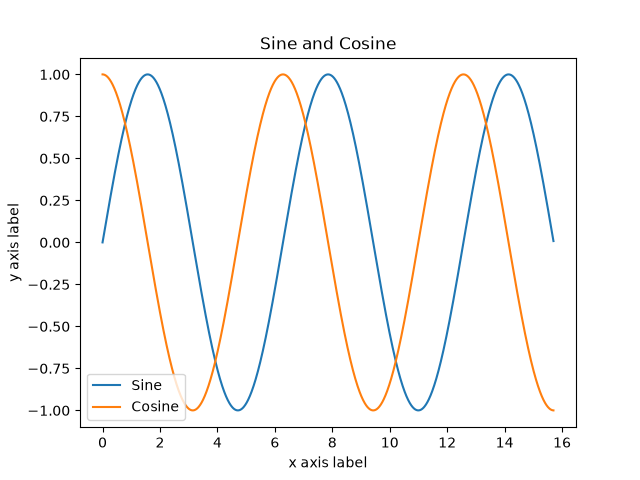

In [10]:
# --- Interactive plots ---
# `%matplotlib widget` (powered by ipympl) makes matplotlib figures interactive
# (zoom/pan) in JupyterLab, Jupyter Notebook 7, and Binder. Google Colab needs two
# extra steps — installing ipympl and enabling its custom widget manager — which we
# do here ONLY when running on Colab (a harmless no-op in every other environment).
import sys
if 'google.colab' in sys.modules:
    %pip install -q ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# Compute the x and y coordinates for points on sine and cosine curves
x = np.arange(0, 5 * np.pi, 0.01)
y_sin = np.sin(x)
y_cos = np.cos(x)

# Plot the points using matplotlib
plt.plot(x, y_sin)
plt.plot(x, y_cos)
plt.xlabel('x axis label')
plt.ylabel('y axis label')
plt.title('Sine and Cosine')
plt.legend(['Sine', 'Cosine'])
plt.show();

## Controlling Line Properties
- https://matplotlib.org/users/pyplot_tutorial.html#controlling-line-properties
- https://matplotlib.org/api/lines_api.html#matplotlib.lines.Line2D

Lines have many attributes that you can set: linewidth, dash style, marker, antialiasing, alpha, and more; see [matplotlib.lines.Line2D](https://matplotlib.org/api/lines_api.html#matplotlib.lines.Line2D). There are several ways to set line properties

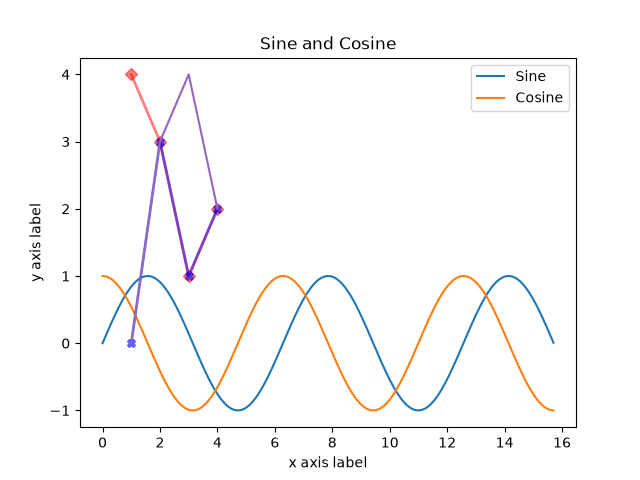

In [11]:
(x1_vals, y1_vals) = ([1,2,3,4], random.sample(range(0, 5), 4))
(x2_vals, y2_vals) = ([1,2,3,4], random.sample(range(0, 5), 4))
(x3_vals, y3_vals) = ([1,2,3,4], random.sample(range(0, 5), 4))

line1 = plt.plot(x1_vals, y1_vals)
line2 = plt.plot(x2_vals, y2_vals)
line3 = plt.plot(x3_vals, y3_vals)
plt.setp(line1, color='r', linewidth=2.0, marker='D', alpha=0.5)
plt.setp(line2, color='b', linewidth=2.0, marker='X', alpha=0.5)
plt.show()

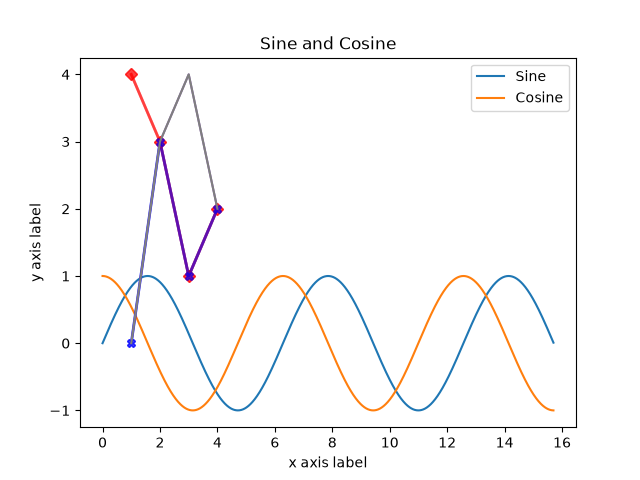

In [12]:
lines = plt.plot(x1_vals, y1_vals, x2_vals, y2_vals, x3_vals, y3_vals)
plt.setp(lines[0], color='r', linewidth=2.0, marker='D', alpha=0.5)
plt.setp(lines[1], color='b', linewidth=2.0, marker='X', alpha=0.5)
plt.show()

You can also set these properties using keyword args in the plot function:

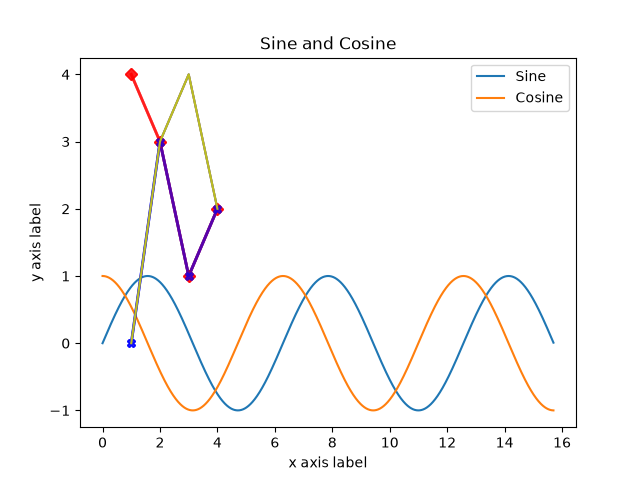

In [13]:
line1 = plt.plot(x1_vals, y1_vals, color='r', linewidth=2.0, marker='D', alpha=0.5)
line2 = plt.plot(x2_vals, y2_vals, color='b', linewidth=2.0, marker='X', alpha=0.5)
line3 = plt.plot(x3_vals, y3_vals)
plt.show()

## Plotting multiple charts

You can create multiple plots within the same figure by using [`subplot`](https://matplotlib.org/gallery/subplots_axes_and_figures/subplot.html)

**References:**
- https://jakevdp.github.io/PythonDataScienceHandbook/04.08-multiple-subplots.html
- https://matplotlib.org/gallery/subplots_axes_and_figures/subplot.html
- https://matplotlib.org/devdocs/gallery/subplots_axes_and_figures/subplots_demo.html

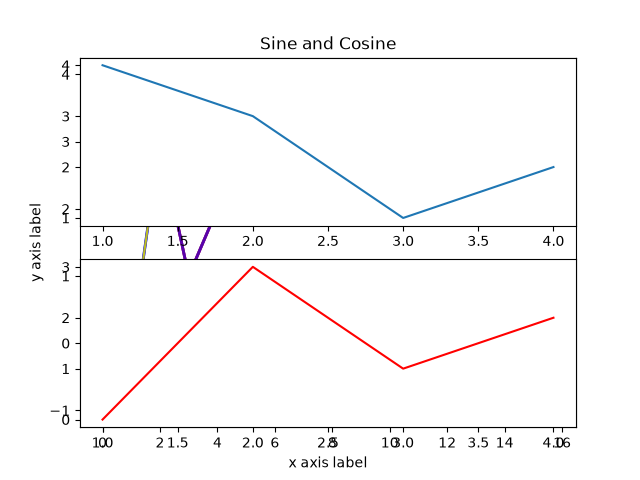

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# subplot adds a subplot to the figure. To set the subplot location, pass
# in a three digit integer (< 10) where the first digit is the number of rows, 
# the second the number of columns, and the third the index of the 
# subplot. So, plt.subplot(211) refers to a two row plot with one 
# column and selects the subplot index. This is equivalent to 
# plt.subplot(2,1,1). See: 
#   https://matplotlib.org/api/_as_gen/matplotlib.pyplot.subplot.html
plt.subplot(211) 
plt.plot(x1_vals, y1_vals)

plt.subplot(212)
plt.plot(x2_vals, y2_vals, 'r-') # the 'r-' colors the line red
plt.show()

In [15]:
# From: https://jakevdp.github.io/PythonDataScienceHandbook/04.08-multiple-subplots.html#plt.subplot:-Simple-Grids-of-Subplots
for i in range(1, 7):
    plt.subplot(2, 3, i)
    plt.text(0.5, 0.5, str((2, 3, i)),
             fontsize=18, ha='center')

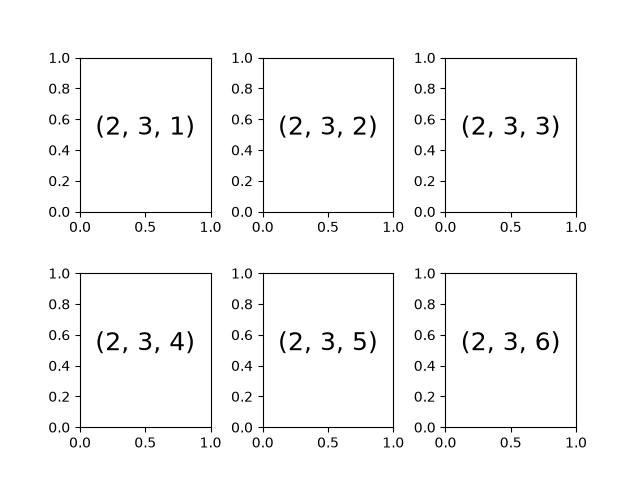

In [16]:
fig = plt.figure()
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(1, 7):
    ax = fig.add_subplot(2, 3, i)
    ax.text(0.5, 0.5, str((2, 3, i)),
           fontsize=18, ha='center')

I typically make my grid of plots in using plt.subplots() (note the **s** in subplots)

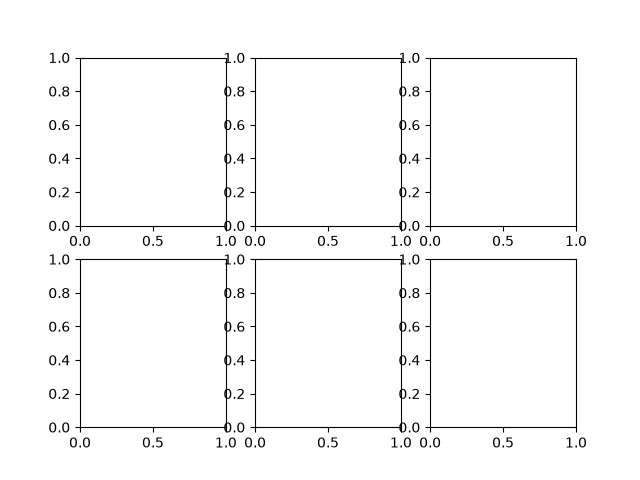

In [17]:
# https://matplotlib.org/api/_as_gen/matplotlib.pyplot.subplots.html
fig, axes = plt.subplots(2, 3) # same as plt.subplots(nrows=2, ncols=3)

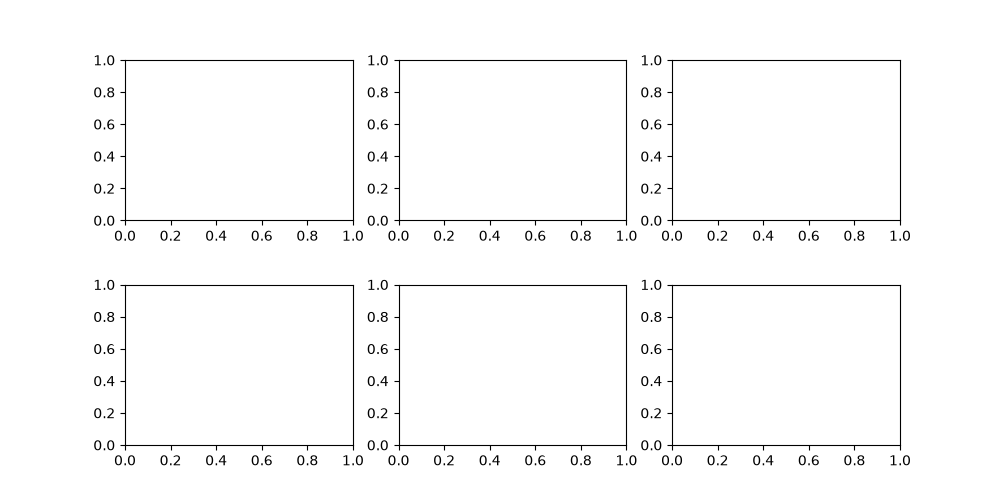

In [18]:
# We can make more room using figsize
fig, axes = plt.subplots(2, 3, figsize=(10,5))
fig.subplots_adjust(hspace=0.4) # add in more height between subplots

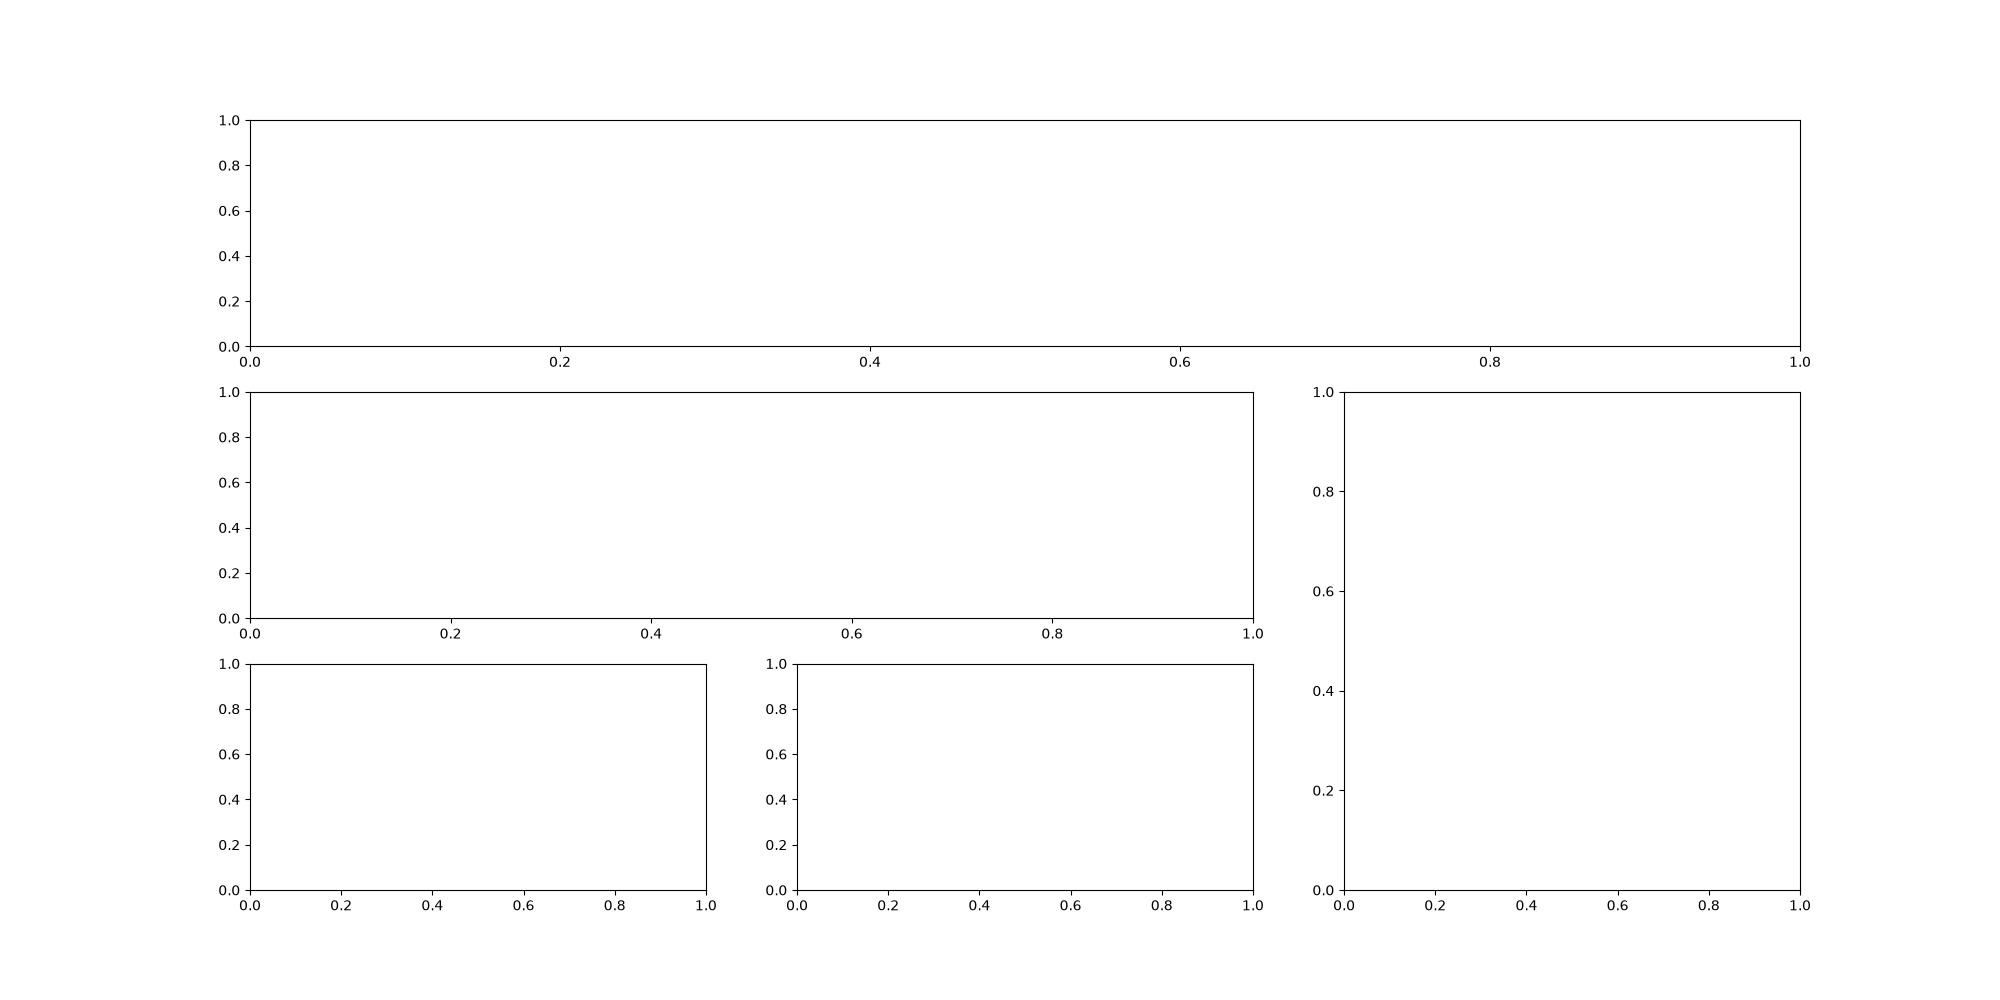

In [19]:
# Grid of different sizes
# See: https://matplotlib.org/users/gridspec.html
plt.figure(figsize=(20,10))
ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=3)
ax2 = plt.subplot2grid((3, 3), (1, 0), colspan=2)
ax3 = plt.subplot2grid((3, 3), (1, 2), rowspan=2)
ax4 = plt.subplot2grid((3, 3), (2, 0))
ax5 = plt.subplot2grid((3, 3), (2, 1))

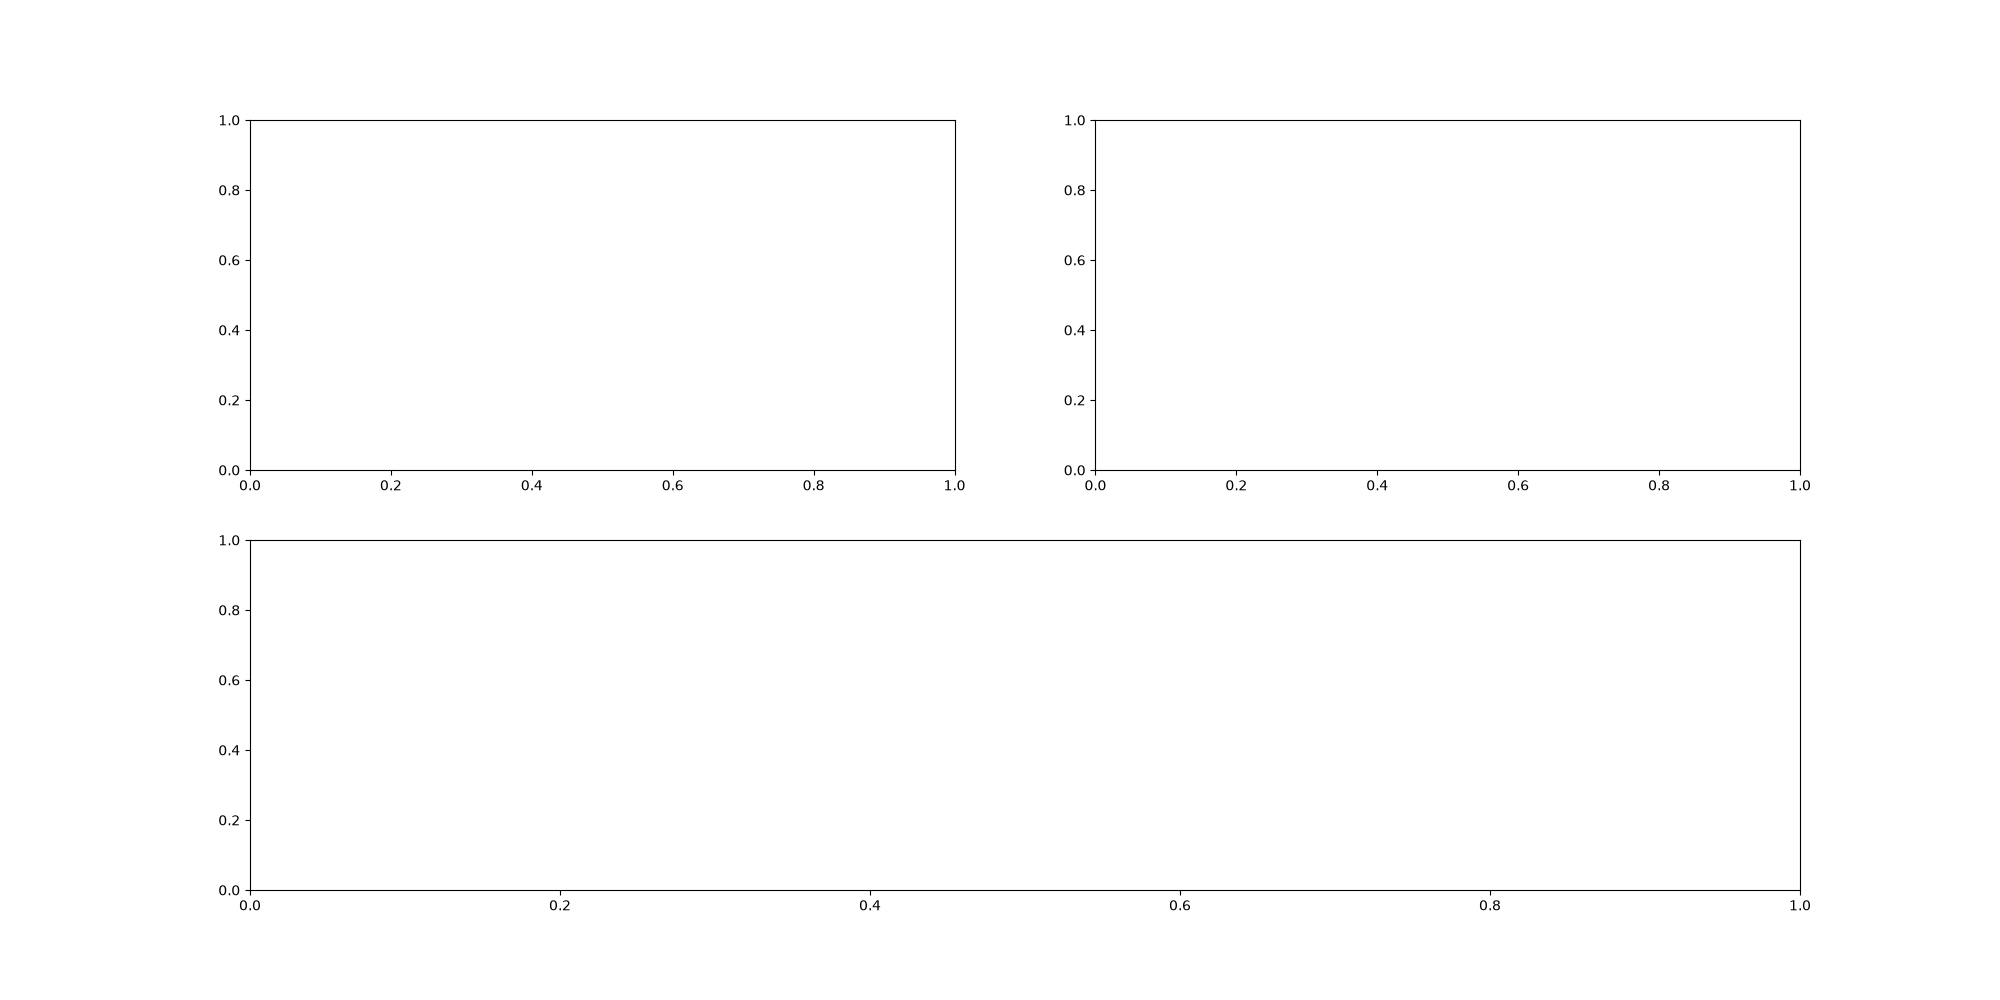

In [20]:
# Grid of different sizes
# See: https://matplotlib.org/users/gridspec.html
plt.figure(figsize=(20,10))
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)



## Specifying Colors, Markers

### Colors
- https://matplotlib.org/2.0.2/api/colors_api.html
- https://matplotlib.org/users/colors.html

In almost all places in matplotlib where a color can be specified by the user it can be provided as:

- an RGB or RGBA tuple of float values in [0, 1] (e.g., (0.1, 0.2, 0.5) or (0.1, 0.2, 0.5, 0.3))
- a hex RGB or RGBA string (e.g., '#0F0F0F' or '#0F0F0F0F')
- a string representation of a float value in [0, 1] inclusive for gray level (e.g., '0.5')
one of {'b', 'g', 'r', 'c', 'm', 'y', 'k', 'w'}
- a X11/CSS4 color name
- a name from the xkcd color survey prefixed with 'xkcd:' (e.g., 'xkcd:sky blue')
- one of {'C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9'}
- one of {'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan'} which are the Tableau Colors from the ‘T10’ categorical palette (which is the default color cycle).

For the basic built-in colors, you can use a single letter

- b: blue
- g: green
- r: red
- c: cyan
- m: magenta
- y: yellow
- k: black
- w: white

### Markers
- https://matplotlib.org/api/markers_api.html

There are lots of different markers, including:

- "." point
- "," pixel
- "o" circle
- "v" triangle_down
- "^" triangle_up
- "<" triangle_left
- ">" triangle_right
- "s" square
- "p" pentagon
- "P" plus (filled)
- "*" star
- "h" hexagon1
- "H" hexagon2
- "+" plus
- "x" x
- "X" x (filled)
- "D" diamond
- "d" thin_diamond

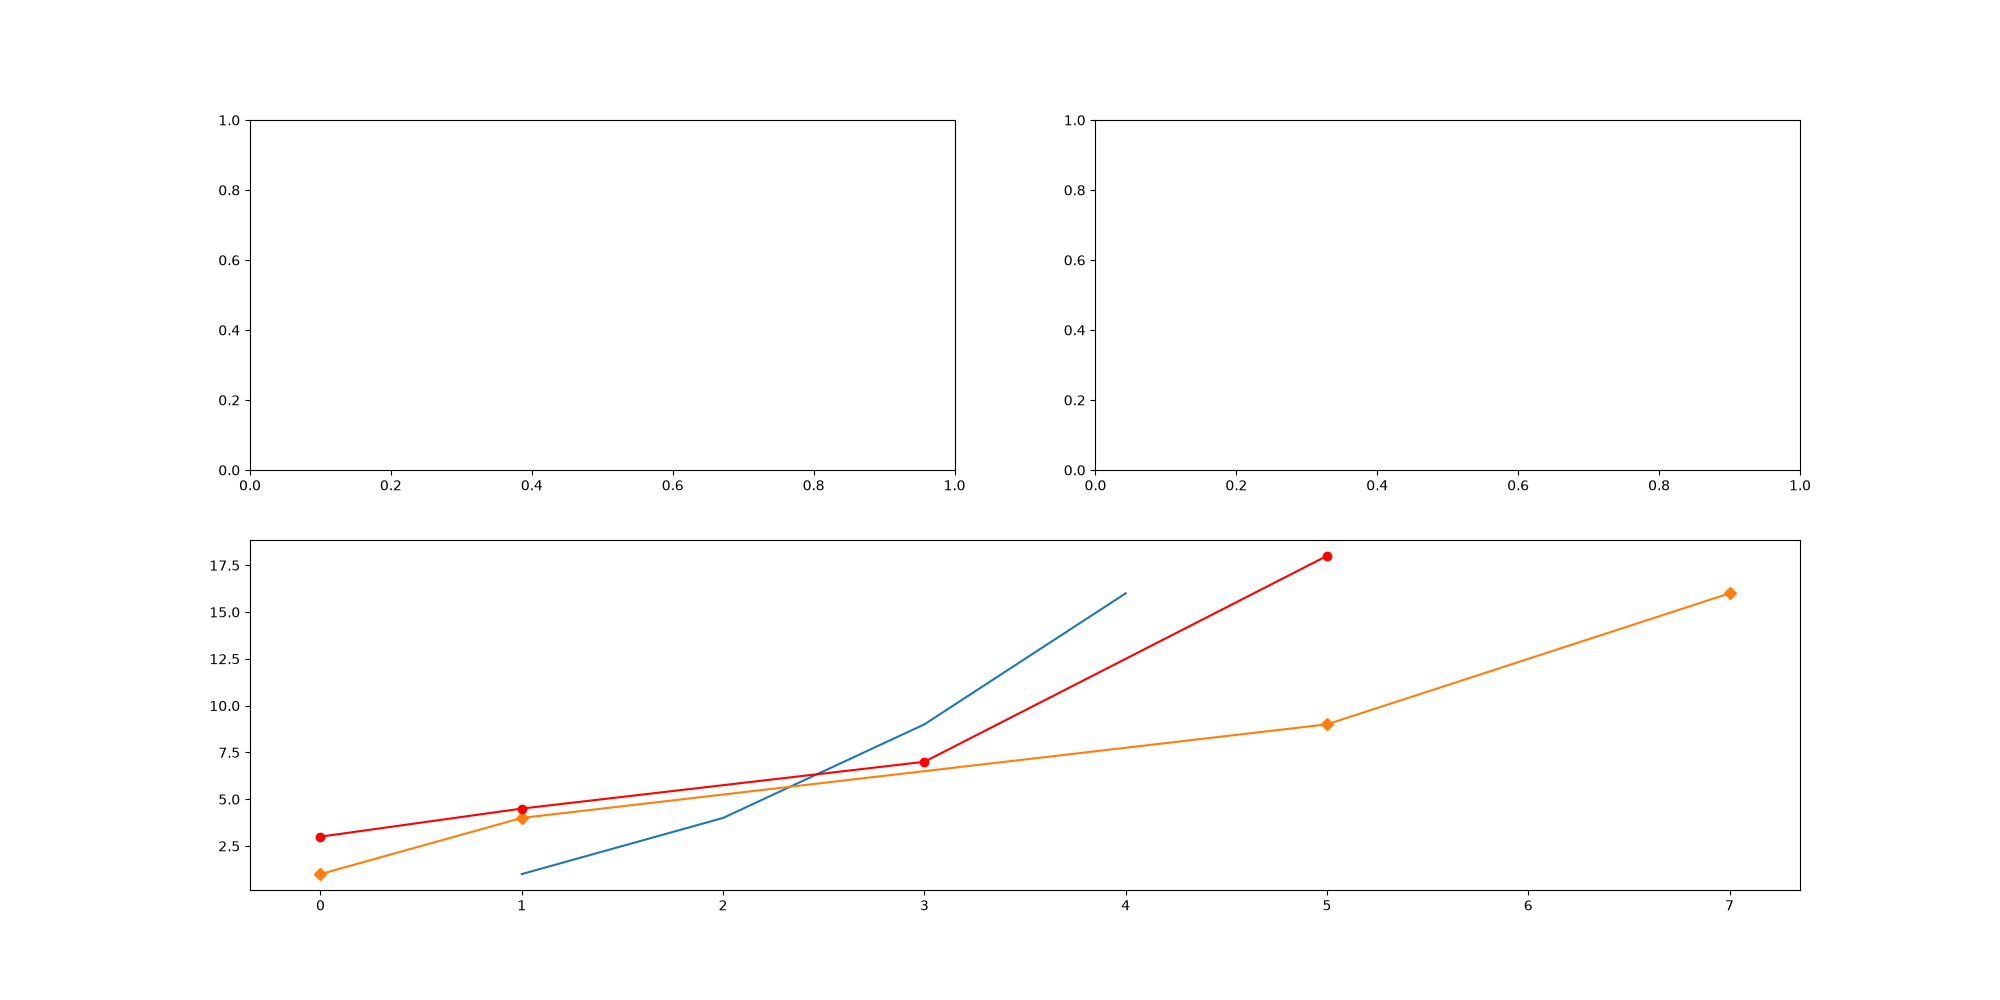

In [21]:
import matplotlib.pyplot as plt
plt.plot([1,2,3,4], [1,4,9,16])
plt.plot([0,1,5,7], [1,4,9,16], 'D-')
plt.plot([0,1,3,5], [3,4.5,7,18], 'ro-')
plt.show()

C:\Users\jonf\AppData\Local\Temp\ipykernel_49308\3181068173.py:14: UserWarning: The pixel maker ',' is not supported on scatter(); using a finite-sized square instead, which is not necessarily 1 pixel in size. Use the square marker 's' instead to suppress this warning.
  plt.scatter(i,j,marker=m)


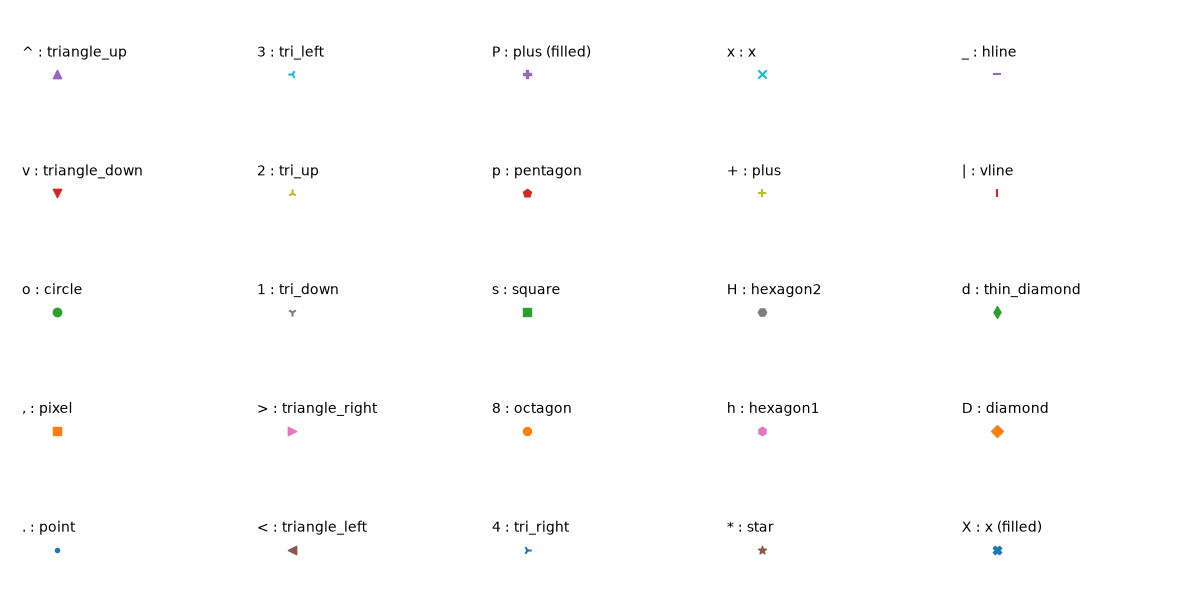

In [22]:
# Example of all markers
# From: https://stackoverflow.com/a/46637880
import matplotlib.pylab as plt
markers=['.',',','o','v','^','<','>','1','2','3','4','8','s','p','P','*','h','H','+','x','X','D','d','|','_']
descriptions=['point', 'pixel', 'circle', 'triangle_down', 'triangle_up','triangle_left', 'triangle_right', 'tri_down', 'tri_up', 'tri_left','tri_right', 'octagon', 'square', 'pentagon', 'plus (filled)','star', 'hexagon1', 'hexagon2', 'plus', 'x', 'x (filled)','diamond', 'thin_diamond', 'vline', 'hline']
x=[]
y=[]
for i in range(5):
    for j in range(5):
        x.append(i)
        y.append(j)
plt.figure(figsize=(12,6))
for i,j,m,l in zip(x,y,markers,descriptions):
    plt.scatter(i,j,marker=m)
    plt.text(i-0.15,j+0.15,s=m+' : '+l)
plt.axis([-0.1,4.8,-0.1,4.5])
plt.tight_layout()
plt.axis('off')
plt.show()  

In [23]:
import numpy as np
import matplotlib.pyplot as plt
markers = [(i,j,0) for i in range(2,10) for j in range(1, 3)]

[plt.plot(i, 0, marker = markers[i], ms=10) for i in range(16)]

[[<matplotlib.lines.Line2D at 0x269d66dfbc0>],